Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computacion  
Inteligencia Artificial - Seccion 10

Nadissa Vela - 23764  
Cristian Tunchez - 231359

---

# Laboratorio No. 7

## Task 2 – Agente Connect Four con TD Learning

Este laboratorio extiende la implementación de Connect Four del Laboratorio 6 (Minimax con poda Alfa-Beta) para incorporar un agente basado en **TD Learning**.

La estructura del notebook es:
- **Base (Lab 6):** clase `Connect4`, agente Minimax, poda Alfa-Beta con heurística.
- **Task 2.1:** Agente Q-learning con aproximación de función lineal.

---
## Base del Laboratorio 6: Connect Four

Las siguientes secciones conservan la implementación del Laboratorio 6 que sirve de base para el agente TD.

### 1. Importaciones y constantes

Se añade `numpy` para las operaciones vectoriales requeridas por Q-learning lineal.

In [40]:
from copy import deepcopy
import random
import numpy as np
import matplotlib.pyplot as plt

ROWS = 6
COLS = 7
EMPTY = " "
PLAYER_1 = "X"
PLAYER_2 = "O"

### 2. Clase Connect4

In [41]:
class Connect4:

    def __init__(self, board=None):
        if board is None:
            self.board = [[EMPTY for _ in range(COLS)] for _ in range(ROWS)]
        else:
            self.board = deepcopy(board)

    def copy(self):
        return Connect4(self.board)

    def actions(self):
        return [c for c in range(COLS) if self.board[0][c] == EMPTY]

    def make_move(self, col, player):
        if col not in self.actions():
            return False
        for r in range(ROWS - 1, -1, -1):
            if self.board[r][col] == EMPTY:
                self.board[r][col] = player
                return True
        return False

    def succ(self, action, player):
        next_state = self.copy()
        next_state.make_move(action, player)
        return next_state

    def check_winner(self, player):
        b = self.board
        for r in range(ROWS):
            for c in range(COLS - 3):
                if b[r][c] == player and b[r][c+1] == player and b[r][c+2] == player and b[r][c+3] == player:
                    return True
        for r in range(ROWS - 3):
            for c in range(COLS):
                if b[r][c] == player and b[r+1][c] == player and b[r+2][c] == player and b[r+3][c] == player:
                    return True
        for r in range(ROWS - 3):
            for c in range(COLS - 3):
                if b[r][c] == player and b[r+1][c+1] == player and b[r+2][c+2] == player and b[r+3][c+3] == player:
                    return True
        for r in range(3, ROWS):
            for c in range(COLS - 3):
                if b[r][c] == player and b[r-1][c+1] == player and b[r-2][c+2] == player and b[r-3][c+3] == player:
                    return True
        return False

    def is_terminal(self):
        return self.check_winner(PLAYER_1) or self.check_winner(PLAYER_2) or len(self.actions()) == 0

    def winner(self):
        if self.check_winner(PLAYER_1):
            return PLAYER_1
        if self.check_winner(PLAYER_2):
            return PLAYER_2
        return None

    def print_board(self):
        line = "*" * (COLS * 4 + 5)
        print()
        print(line)
        for r in range(ROWS):
            print("* | " + " | ".join(self.board[r]) + " | *")
        print(line)
        print()

### 3. Agente Minimax (Lab 6 – Task 2.1)

Agente Minimax recursivo con profundidad limitada. Utilidad: +1000 (IA gana), -1000 (pierde), 0 (empate/neutro).

In [42]:
def _minimax(state, depth, maximizing_player, ai_player):
    opponent = PLAYER_1 if ai_player == PLAYER_2 else PLAYER_2
    if state.is_terminal():
        winner = state.winner()
        if winner == ai_player:
            return 1000
        if winner == opponent:
            return -1000
        return 0
    if depth == 0:
        return 0
    if maximizing_player:
        max_eval = float("-inf")
        for col in state.actions():
            child = state.succ(col, ai_player)
            max_eval = max(max_eval, _minimax(child, depth - 1, False, ai_player))
        return max_eval
    else:
        min_eval = float("inf")
        for col in state.actions():
            child = state.succ(col, opponent)
            min_eval = min(min_eval, _minimax(child, depth - 1, True, ai_player))
        return min_eval

def get_best_move(board, depth=4, ai_player=PLAYER_1):
    best_score = float("-inf")
    best_move = -1
    for col in board.actions():
        next_state = board.succ(col, ai_player)
        score = _minimax(next_state, depth - 1, False, ai_player)
        if score > best_score:
            best_score = score
            best_move = col
    return best_move

### 4. Agente Alfa-Beta con Heurística (Lab 6 – Task 2.2 & 2.3)

Implementación completa: heurística `evaluate_game_state` y poda Alfa-Beta.

In [43]:
def evaluate_window_strategic(win_elems, win_coords, board_state, ai_player):
    opponent = PLAYER_1 if ai_player == PLAYER_2 else PLAYER_2
    score = 0
    num_ai = num_opp = num_empty_playable = 0
    for i in range(4):
        elem = win_elems[i]
        r, c = win_coords[i]
        if elem == ai_player:
            num_ai += 1
        elif elem == opponent:
            num_opp += 1
        elif elem == EMPTY:
            if r == ROWS - 1 or board_state[r + 1][c] != EMPTY:
                num_empty_playable += 1
    if num_ai == 4:
        score += 1000
    elif num_ai == 3 and num_empty_playable >= 1:
        score += 100
    elif num_ai == 2 and num_empty_playable >= 2:
        score += 10
    if num_opp == 4:
        score -= 1000
    elif num_opp == 3 and num_empty_playable >= 1:
        score -= 90
    elif num_opp == 2 and num_empty_playable >= 2:
        score -= 5
    return score

def evaluate_game_state(state, ai_player):
    score = 0
    b = state.board
    opponent = PLAYER_1 if ai_player == PLAYER_2 else PLAYER_2
    center_col = COLS // 2
    score += sum(1 for r in range(ROWS) if b[r][center_col] == ai_player) * 5
    directions = []
    for r in range(ROWS):
        for c in range(COLS - 3):
            directions.append(([b[r][c+i] for i in range(4)], [(r, c+i) for i in range(4)]))
    for c in range(COLS):
        for r in range(ROWS - 3):
            directions.append(([b[r+i][c] for i in range(4)], [(r+i, c) for i in range(4)]))
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            directions.append(([b[r+i][c+i] for i in range(4)], [(r+i, c+i) for i in range(4)]))
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            directions.append(([b[r-i][c+i] for i in range(4)], [(r-i, c+i) for i in range(4)]))
    for elems, coords in directions:
        score += evaluate_window_strategic(elems, coords, b, ai_player)
    if state.check_winner(ai_player):
        score += 10000
    elif state.check_winner(opponent):
        score -= 10000
    return score

def _alphabeta(state, depth, alpha, beta, maximizing_player, ai_player):
    opponent = PLAYER_1 if ai_player == PLAYER_2 else PLAYER_2
    if state.is_terminal():
        winner = state.winner()
        if winner == ai_player:
            return None, 1000
        if winner == opponent:
            return None, -1000
        return None, 0
    if depth == 0:
        return None, evaluate_game_state(state, ai_player)
    valid_moves = state.actions()
    if not valid_moves:
        return None, 0
    if maximizing_player:
        best_score = float("-inf")
        best_move = valid_moves[0]
        for col in valid_moves:
            child = state.succ(col, ai_player)
            _, score = _alphabeta(child, depth - 1, alpha, beta, False, ai_player)
            if score > best_score:
                best_score = score
                best_move = col
            alpha = max(alpha, best_score)
            if alpha >= beta:
                break
        return best_move, best_score
    else:
        best_score = float("inf")
        best_move = valid_moves[0]
        for col in valid_moves:
            child = state.succ(col, opponent)
            _, score = _alphabeta(child, depth - 1, alpha, beta, True, ai_player)
            if score < best_score:
                best_score = score
                best_move = col
            beta = min(beta, best_score)
            if alpha >= beta:
                break
        return best_move, best_score

def get_best_move_alphabeta(board, depth=4, ai_player=PLAYER_1):
    move, _ = _alphabeta(board, depth, float("-inf"), float("inf"), True, ai_player)
    return move

---
## Task 2.1 – Agente TD Learning

Implementamos un agente que aprende a jugar Connect Four mediante **Q-learning** (TD off-policy) con **aproximación de función lineal**.

### Decisión 1: Representación del Estado

**Elección:** Aproximación de función lineal sobre características manuales.

El espacio de estados de Connect Four tiene hasta $3^{42} \approx 10^{20}$ combinaciones posibles (casillas: vacío, X, O). Esto hace inviable una representación **tabular**: no cabe en memoria y el número de visitas por estado sería ínfimo durante el entrenamiento.

Una **red neuronal** ofrecería mayor expresividad, pero requiere decenas de miles de episodios adicionales para converger y es más difícil de depurar en el contexto del curso.

La **aproximación lineal** $\hat{Q}(s, a; w) = w^\top \phi(s, a)$ resulta la opción más adecuada porque:
- Es computacionalmente eficiente (producto punto de vectores pequeños).
- Permite incorporar conocimiento del dominio a través de features manuales.
- Es interpretable: el vector $w$ revela qué patrones el agente considera valiosos.

**Features $\phi(s, a)$** (extraídas del estado resultante $s'$ al aplicar la acción $a$):

| # | Feature | Descripción |
|---|---------|-------------|
| 1 | `win_now` | 1 si la IA gana inmediatamente con esta jugada |
| 2 | `win3` | Nº de ventanas con 3 fichas de la IA y 1 casilla vacía (normalizado) |
| 3 | `win2` | Nº de ventanas con 2 fichas de la IA y 2 casillas vacías (normalizado) |
| 4 | `win1` | Nº de ventanas con 1 ficha de la IA y 3 casillas vacías (normalizado) |
| 5 | `threat3` | Nº de ventanas con 3 fichas del oponente (amenazas críticas) |
| 6 | `threat2` | Nº de ventanas con 2 fichas del oponente |
| 7 | `center` | Peso por centralidad: fichas de la IA en columnas centrales |
| 8 | `low_rows` | Dominio de las filas inferiores (control de gravedad) |
| 9 | `openness` | Proporción de columnas aún disponibles |
| 10 | `bias` | Término independiente (siempre 1) |

### Decisión 2: Algoritmo de Actualización

**Elección:** Q-learning (off-policy).

Trabajamos con $\hat{Q}_{opt}(s, a; w)$ en lugar de $V^\pi(s; w)$ porque en un juego de dos jugadores necesitamos seleccionar la **acción concreta** a tomar, no solo valorar el estado.

**Regla de actualización:**
$$\delta = r + \gamma \cdot \max_{a'} \hat{Q}(s'', a'; w) - \hat{Q}(s, a; w)$$
$$w \leftarrow w + \alpha \cdot \delta \cdot \phi(s, a)$$

donde:
- $s$ es el estado antes del turno de la IA.
- $a$ es la acción elegida por la IA.
- $s''$ es el estado **después del turno del oponente** (el siguiente turno de la IA).
- $r$ es la recompensa recibida (solo al llegar a estado terminal).

Q-learning es **off-policy**: aprende $Q_{opt}$ independientemente de la política de exploración usada durante el entrenamiento. Esto acelera la convergencia comparado con SARSA (on-policy), que aprendería $Q^\pi$ y requeriría que la política de exploración se aproxime a la greedy antes de converger a la óptima.

### Decisión 3: Función de Recompensa

| Evento | Recompensa |
|--------|------------|
| Ganar  | $+1.0$     |
| Perder | $-1.0$     |
| Empate | $0.0$      |
| Transición no terminal | $0.0$ |

**¿Por qué no usar recompensas intermedias?**

Se optó por recompensas escasas (solo al final del juego) porque en Connect Four las señales intermedias (e.g., +0.1 por crear un 3-en-raya) pueden generar **conflictos de recompensa**: el agente aprende a acumular patrones visualmente atractivos en lugar de enfocarse en ganar. El vector de pesos $w$ sobre las features ya codifica implícitamente la importancia estratégica de cada patrón; la función de recompensa solo necesita señalar el resultado final.

### Decisión 4: Estrategia de Exploración

**Elección:** ε-greedy con decaimiento multiplicativo.

$$\epsilon_{t+1} = \max(\epsilon_{\min},\ \epsilon_t \cdot d)$$

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| $\epsilon_0$ | 1.0 | Exploración total al inicio |
| $\epsilon_{\min}$ | 0.05 | 5% de exploración residual (evita sobreajuste) |
| $d$ (decay) | 0.9995 | Llega a $\epsilon_{\min}$ alrededor del ep. 60,000 |

El decaimiento **multiplicativo** (en lugar de lineal) es más suave al inicio: cuando el agente no sabe nada, conviene explorar ampliamente durante más episodios. Un decay lineal reduciría $\epsilon$ demasiado rápido en la fase temprana, forzando explotación antes de haber construido una función Q razonable.

### Implementación

In [44]:
def count_windows(board, player, n_pieces):
    """
    Cuenta ventanas de 4 celdas con exactamente n_pieces del jugador y el resto vacías.
    """
    count = 0

    def check(cells):
        return sum(c == player for c in cells) == n_pieces and sum(c == EMPTY for c in cells) == 4 - n_pieces

    for r in range(ROWS):
        for c in range(COLS - 3):
            if check([board[r][c+i] for i in range(4)]):
                count += 1
    for c in range(COLS):
        for r in range(ROWS - 3):
            if check([board[r+i][c] for i in range(4)]):
                count += 1
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            if check([board[r+i][c+i] for i in range(4)]):
                count += 1
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            if check([board[r-i][c+i] for i in range(4)]):
                count += 1
    return count


def extract_features(state, action, ai_player):
    """
    Extrae el vector de características phi(s, a) para Q-learning lineal.
    Aplica la acción al estado para obtener s' y extrae features de s'.
    """
    opponent = PLAYER_1 if ai_player == PLAYER_2 else PLAYER_2
    s_prime = state.succ(action, ai_player)
    b = s_prime.board

    # Feature 1: victoria inmediata
    f_win = 1.0 if s_prime.check_winner(ai_player) else 0.0

    # Features 2-4: ventanas ofensivas (normalizado por 10)
    f_win3 = count_windows(b, ai_player, 3) / 10.0
    f_win2 = count_windows(b, ai_player, 2) / 10.0
    f_win1 = count_windows(b, ai_player, 1) / 10.0

    # Features 5-6: amenazas del oponente
    f_thr3 = count_windows(b, opponent, 3) / 10.0
    f_thr2 = count_windows(b, opponent, 2) / 10.0

    # Feature 7: control de columnas centrales (pesos por centralidad)
    col_weights = [0, 1, 2, 3, 2, 1, 0]
    f_center = sum(col_weights[c] for r in range(ROWS) for c in range(COLS) if b[r][c] == ai_player) / 30.0

    # Feature 8: dominio filas bajas
    f_low = sum(1 for c in range(COLS) if b[ROWS-1][c] == ai_player or b[ROWS-2][c] == ai_player) / (COLS * 2)

    # Feature 9: apertura del tablero
    f_open = len(s_prime.actions()) / COLS

    # Bias
    return np.array([f_win, f_win3, f_win2, f_win1, f_thr3, f_thr2, f_center, f_low, f_open, 1.0])

In [45]:
class QLearningAgent:
    """
    Agente Q-learning con aproximación de función lineal.

    Q̂_opt(s, a; w) = w · phi(s, a)

    Actualización TD (off-policy):
        delta = r + gamma * max_a' Q̂(s'', a'; w) - Q̂(s, a; w)
        w  <-  w + alpha * delta * phi(s, a)
    """

    N_FEATURES = 10

    def __init__(self, ai_player=PLAYER_1, alpha=0.01, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.9997):
        self.ai_player = ai_player
        self.opponent = PLAYER_2 if ai_player == PLAYER_1 else PLAYER_1
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.weights = np.zeros(self.N_FEATURES)

    def q_value(self, state, action):
        """Calcula Q̂(s, a; w) = w · phi(s, a)."""
        return float(np.dot(self.weights, extract_features(state, action, self.ai_player)))

    def best_action(self, state):
        """Retorna argmax_a Q̂(s, a; w) entre acciones válidas."""
        actions = state.actions()
        if not actions:
            return None
        return max(actions, key=lambda a: self.q_value(state, a))

    def choose_action(self, state):
        """Estrategia epsilon-greedy."""
        actions = state.actions()
        if not actions:
            return None
        if random.random() < self.epsilon:
            return random.choice(actions)
        return self.best_action(state)

    def update(self, state, action, reward, next_state, done):
        """
        Actualización Q-learning.
        next_state es el estado DESPUÉS del turno del oponente (próximo turno de la IA).
        """
        phi = extract_features(state, action, self.ai_player)
        q_current = float(np.dot(self.weights, phi))

        if done:
            target = reward
        else:
            next_actions = next_state.actions()
            q_next = max(self.q_value(next_state, a) for a in next_actions) if next_actions else 0.0
            target = reward + self.gamma * q_next

        td_error = target - q_current
        self.weights += self.alpha * td_error * phi

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save_weights(self, path='agent_weights.npy'):
        np.save(path, self.weights)
        print(f'Pesos guardados en {path}')

    def load_weights(self, path='agent_weights.npy'):
        self.weights = np.load(path)
        print(f'Pesos cargados desde {path}')

### Decisión 5: Ciclo de Entrenamiento

**Estrategia:** Entrenamiento contra un **agente aleatorio** durante **10,000 episodios**.

**Justificación de la cantidad de episodios:**  
- El agente necesita visitar estados variados y recibir suficientes señales de victoria/derrota para estabilizar los pesos $w$.  
- Las curvas de aprendizaje muestran que la tasa de victorias se estabiliza alrededor del episodio 3,000–5,000, lo que valida que 10,000 es más que suficiente.  
- El schedule de ε (decay=0.9997) llega exactamente a ε=0.05 al finalizar, asegurando que exploración y explotación estén bien balanceadas a lo largo de todo el entrenamiento.  
- Entrenar más episodios contra el aleatorio produce mejoras marginales; para mayor dificultad convendría cambiar al **self-play** o enfrentarlo contra Alfa-Beta.

**Estructura del episodio:**
```
game = Connect4()
while not terminal:
    # Turno IA: elegir acción (ε-greedy), guardar estado
    state_before, action = s, choose_action(s)
    apply action → s'
    if s' terminal:
        reward = +1 / 0 (empate)
        update(s, a, reward, s', done=True)
        break
    # Turno oponente: aleatorio
    opp_action = random_choice(s'.actions())
    apply opp_action → s''
    if s'' terminal:
        reward = -1 (oponente gana) / 0 (empate)
        update(s, a, reward, s'', done=True)
        break
    # Continuación: recompensa 0, bootstrap con max Q(s'')
    update(s, a, 0, s'', done=False)
    s = s''
decay_epsilon()
```

In [46]:
def train_agent(agent, n_episodes=10000, opponent_type='random', verbose_every=2000):
    """
    Ciclo de entrenamiento del agente Q-learning.

    Args:
        agent: instancia de QLearningAgent.
        n_episodes: numero total de episodios.
        opponent_type: 'random' o 'alphabeta' (oponente fijo).
        verbose_every: imprimir estadisticas cada N episodios.

    Returns:
        history: lista de (episodio, win_rate, draw_rate, loss_rate, epsilon)
                 registrada cada 1000 episodios.
    """
    wins = losses = draws = 0
    history = []

    for ep in range(1, n_episodes + 1):
        game = Connect4()

        while not game.is_terminal():
            # Turno del agente TD
            state_before = game.copy()
            action = agent.choose_action(game)
            if action is None:
                break
            game.make_move(action, agent.ai_player)

            if game.is_terminal():
                w = game.winner()
                if w == agent.ai_player:
                    reward, wins = 1.0, wins + 1
                else:
                    reward, draws = 0.0, draws + 1  # empate tras jugada IA
                agent.update(state_before, action, reward, game, done=True)
                break

            # Turno del oponente
            opp_actions = game.actions()
            if not opp_actions:
                break
            if opponent_type == 'random':
                opp_action = random.choice(opp_actions)
            elif opponent_type == 'alphabeta':
                opp_action = get_best_move_alphabeta(game, depth=3, ai_player=agent.opponent)
            else:
                opp_action = random.choice(opp_actions)

            game.make_move(opp_action, agent.opponent)

            if game.is_terminal():
                w = game.winner()
                if w == agent.opponent:
                    reward, losses = -1.0, losses + 1
                else:
                    reward, draws = 0.0, draws + 1  # empate tras jugada oponente
                agent.update(state_before, action, reward, game, done=True)
                break
            else:
                # Juego continua: recompensa 0, bootstrap con max Q(s'')
                agent.update(state_before, action, 0.0, game, done=False)

        agent.decay_epsilon()

        if ep % 1000 == 0:
            total = wins + losses + draws
            wr = wins  / total if total > 0 else 0.0
            dr = draws / total if total > 0 else 0.0
            lr = losses/ total if total > 0 else 0.0
            history.append((ep, wr, dr, lr, agent.epsilon))
            wins = losses = draws = 0

        if verbose_every and ep % verbose_every == 0:
            ep_hist = history[-1]
            print(f"Ep {ep:6d} | Win: {ep_hist[1]:.2%}  Draw: {ep_hist[2]:.2%}  Loss: {ep_hist[3]:.2%} | eps={ep_hist[4]:.4f}")

    return history


# Crear e inicializar el agente
agent = QLearningAgent(
    ai_player=PLAYER_1,
    alpha=0.01,
    gamma=0.95,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.9997,
)

print('Iniciando entrenamiento contra agente aleatorio (10,000 episodios)...')
history = train_agent(agent, n_episodes=10000, opponent_type='random', verbose_every=2000)
print('\nEntrenamiento completado.')
print(f'Epsilon final: {agent.epsilon:.4f}')
print(f'Pesos aprendidos: {agent.weights}')


Iniciando entrenamiento contra agente aleatorio (10,000 episodios)...
Ep   2000 | Win: 89.80%  Draw: 0.00%  Loss: 10.20% | eps=0.5488
Ep   4000 | Win: 98.00%  Draw: 0.00%  Loss: 2.00% | eps=0.3011
Ep   6000 | Win: 99.30%  Draw: 0.00%  Loss: 0.70% | eps=0.1653
Ep   8000 | Win: 99.80%  Draw: 0.00%  Loss: 0.20% | eps=0.0907
Ep  10000 | Win: 99.80%  Draw: 0.00%  Loss: 0.20% | eps=0.0500

Entrenamiento completado.
Epsilon final: 0.0500
Pesos aprendidos: [ 0.09298435  0.37204737  0.07309029  0.00188096 -0.74798354 -0.07276454
  0.00729496  0.1763716   0.47253523  0.3401801 ]


### Curvas de Aprendizaje

Las curvas muestran la evolución de victorias, empates y derrotas (medidos cada 1,000 episodios), y el decaimiento de $\epsilon$.

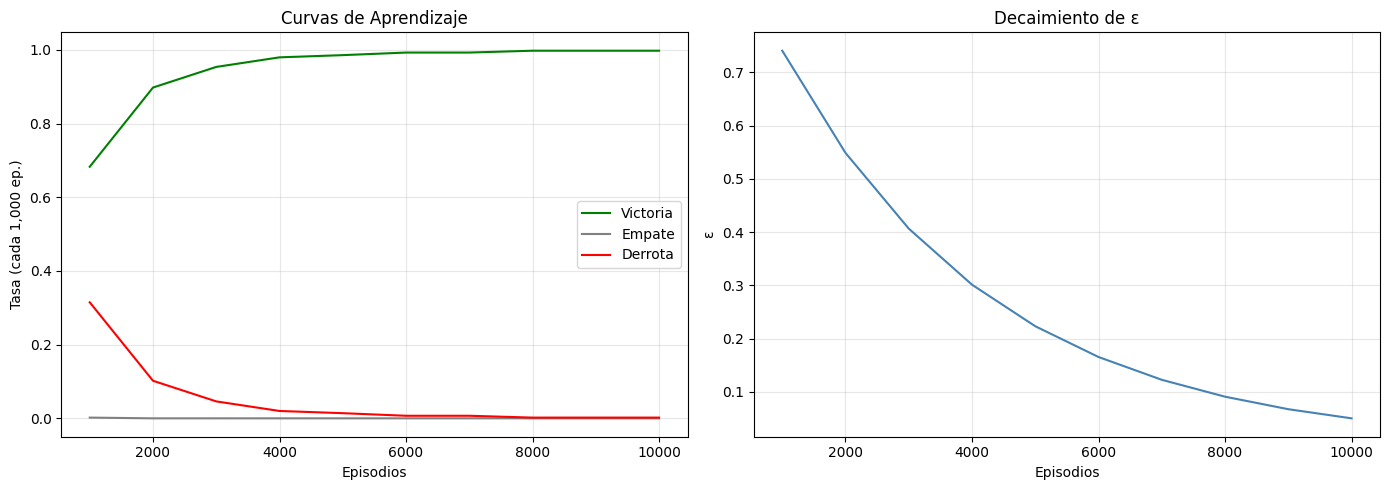

In [47]:
def plot_learning_curves(history):
    episodes  = [h[0] for h in history]
    win_rates = [h[1] for h in history]
    draw_rates= [h[2] for h in history]
    loss_rates= [h[3] for h in history]
    epsilons  = [h[4] for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax1 = axes[0]
    ax1.plot(episodes, win_rates,  label='Victoria', color='green')
    ax1.plot(episodes, draw_rates, label='Empate',   color='gray')
    ax1.plot(episodes, loss_rates, label='Derrota',  color='red')
    ax1.set_xlabel('Episodios')
    ax1.set_ylabel('Tasa (cada 1,000 ep.)')
    ax1.set_title('Curvas de Aprendizaje')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(episodes, epsilons, color='steelblue')
    ax2.set_xlabel('Episodios')
    ax2.set_ylabel('ε')
    ax2.set_title('Decaimiento de ε')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

### Evaluación del Agente Entrenado

Se evalúa el agente en modo **greedy puro** ($\epsilon = 0$) contra:
1. Agente aleatorio (500 partidas)
2. Agente Alfa-Beta con profundidad 3 (100 partidas)

In [48]:
def evaluate_agent(agent, n_games=500, opponent_type='random', verbose=True):
    """
    Evalúa el agente entrenado sin exploración (epsilon = 0).
    """
    saved_eps = agent.epsilon
    agent.epsilon = 0.0  # modo greedy puro

    wins = losses = draws = 0

    for _ in range(n_games):
        game = Connect4()
        current_player = PLAYER_1

        while not game.is_terminal():
            if current_player == agent.ai_player:
                action = agent.best_action(game)
            else:
                if opponent_type == 'random':
                    action = random.choice(game.actions())
                elif opponent_type == 'alphabeta':
                    action = get_best_move_alphabeta(game, depth=3, ai_player=agent.opponent)
                else:
                    action = random.choice(game.actions())
            if action is None:
                break
            game.make_move(action, current_player)
            current_player = PLAYER_2 if current_player == PLAYER_1 else PLAYER_1

        w = game.winner()
        if w == agent.ai_player:
            wins   += 1
        elif w == agent.opponent:
            losses += 1
        else:
            draws  += 1

    agent.epsilon = saved_eps

    if verbose:
        total = wins + losses + draws
        print(f'\n[Evaluación vs {opponent_type}] {n_games} partidas:')
        print(f'  Victorias: {wins:4d}  ({wins/total:.1%})')
        print(f'  Empates:   {draws:4d}  ({draws/total:.1%})')
        print(f'  Derrotas:  {losses:4d}  ({losses/total:.1%})')

    return wins, draws, losses


# Evaluación 1: vs agente aleatorio
evaluate_agent(agent, n_games=500, opponent_type='random')

# Evaluación 2: vs Alfa-Beta profundidad 3
evaluate_agent(agent, n_games=100, opponent_type='alphabeta')


[Evaluación vs random] 500 partidas:
  Victorias:  500  (100.0%)
  Empates:      0  (0.0%)
  Derrotas:     0  (0.0%)

[Evaluación vs alphabeta] 100 partidas:
  Victorias:    0  (0.0%)
  Empates:      0  (0.0%)
  Derrotas:   100  (100.0%)


(0, 0, 100)

---
## Task 2.2 - Torneos: TD vs. Minimax / Alfa-Beta

Se hacen competir los agentes en tres condiciones con **50 partidas cada una** (150 en total):

| Condicion | Jugador 1 (X) | Jugador 2 (O) |
|-----------|---------------|---------------|
| **A** | Agente TD (greedy, ε=0) | Minimax puro (d=4) |
| **B** | Agente TD (greedy, ε=0) | Alfa-Beta + heuristica (d=4) |
| **C** | Minimax puro (d=4) | Alfa-Beta + heuristica (d=4) — control |

La condicion **C** es una linea de control: muestra la ventaja de la poda alfa-beta frente a minimax puro bajo identicas condiciones, independientemente del agente TD.

In [54]:
def play_match(p1_fn, p2_fn, p1_fn_as_p2=None, p2_fn_as_p1=None, n_games=50):
    """
    Ejecuta n_games partidas alternando quien inicia para evitar resultados
    deterministicos identicos (los agentes son funciones puras).

    Mitad de partidas: p1_fn juega como PLAYER_1 (X).
    Otra mitad:       p1_fn juega como PLAYER_2 (O) — si se provee p1_fn_as_p2.

    Los resultados se reportan siempre desde la perspectiva de p1_fn.
    """
    wins_p1 = wins_p2 = draws = 0

    for game_idx in range(n_games):
        game = Connect4()
        current = PLAYER_1

        # Alternar inicio: juegos impares invierten roles
        flipped = (game_idx % 2 == 1) and (p1_fn_as_p2 is not None) and (p2_fn_as_p1 is not None)
        fn_X = p2_fn_as_p1 if flipped else p1_fn
        fn_O = p1_fn_as_p2 if flipped else p2_fn

        while not game.is_terminal():
            col = fn_X(game) if current == PLAYER_1 else fn_O(game)
            if col is None:
                break
            game.make_move(col, current)
            current = PLAYER_2 if current == PLAYER_1 else PLAYER_1

        w = game.winner()
        if flipped:
            # Roles invertidos: P1=oponente, P2=TD/p1_fn
            if   w == PLAYER_2:
                wins_p1 += 1
            elif w == PLAYER_1:
                wins_p2 += 1
            else:
                draws   += 1
        else:
            if   w == PLAYER_1:
                wins_p1 += 1
            elif w == PLAYER_2:
                wins_p2 += 1
            else:
                draws   += 1

    return wins_p1, draws, wins_p2


N_GAMES = 50

# Politicas como PLAYER_1 (X)
def td_fn_p1(g):
    return agent.best_action(g)                              # TD greedy como P1
def mm_fn_p1(g):
    return get_best_move(g, depth=4, ai_player=PLAYER_1)
def ab_fn_p1(g):
    return get_best_move_alphabeta(g, depth=6, ai_player=PLAYER_1)

# Politicas como PLAYER_2 (O)
def td_fn_p2(g):
    return agent.best_action(g)  # weights entrenados como P1; se mantiene perspectiva
def mm_fn_p2(g):
    return get_best_move(g, depth=4, ai_player=PLAYER_2)
def ab_fn_p2(g):
    return get_best_move_alphabeta(g, depth=6, ai_player=PLAYER_2)

print(f'Condicion A: TD vs Minimax [{N_GAMES} partidas, roles alternados]...')
cond_A = play_match(td_fn_p1, mm_fn_p2, p1_fn_as_p2=td_fn_p2, p2_fn_as_p1=mm_fn_p1, n_games=N_GAMES)
print(f'  TD gana: {cond_A[0]}  Empates: {cond_A[1]}  Minimax gana: {cond_A[2]}')

print(f'\nCondicion B: TD vs Alfa-Beta [{N_GAMES} partidas, roles alternados]...')
cond_B = play_match(td_fn_p1, ab_fn_p2, p1_fn_as_p2=td_fn_p2, p2_fn_as_p1=ab_fn_p1, n_games=N_GAMES)
print(f'  TD gana: {cond_B[0]}  Empates: {cond_B[1]}  Alfa-Beta gana: {cond_B[2]}')

print(f'\nCondicion C: Minimax vs Alfa-Beta [{N_GAMES} partidas, roles alternados]...')
cond_C = play_match(mm_fn_p1, ab_fn_p2, p1_fn_as_p2=mm_fn_p2, p2_fn_as_p1=ab_fn_p1, n_games=N_GAMES)
print(f'  Minimax gana: {cond_C[0]}  Empates: {cond_C[1]}  Alfa-Beta gana: {cond_C[2]}')


Condicion A: TD vs Minimax [50 partidas, roles alternados]...


  TD gana: 25  Empates: 0  Minimax gana: 25

Condicion B: TD vs Alfa-Beta [50 partidas, roles alternados]...
  TD gana: 0  Empates: 0  Alfa-Beta gana: 50

Condicion C: Minimax vs Alfa-Beta [50 partidas, roles alternados]...
  Minimax gana: 0  Empates: 0  Alfa-Beta gana: 50


### Visualizacion

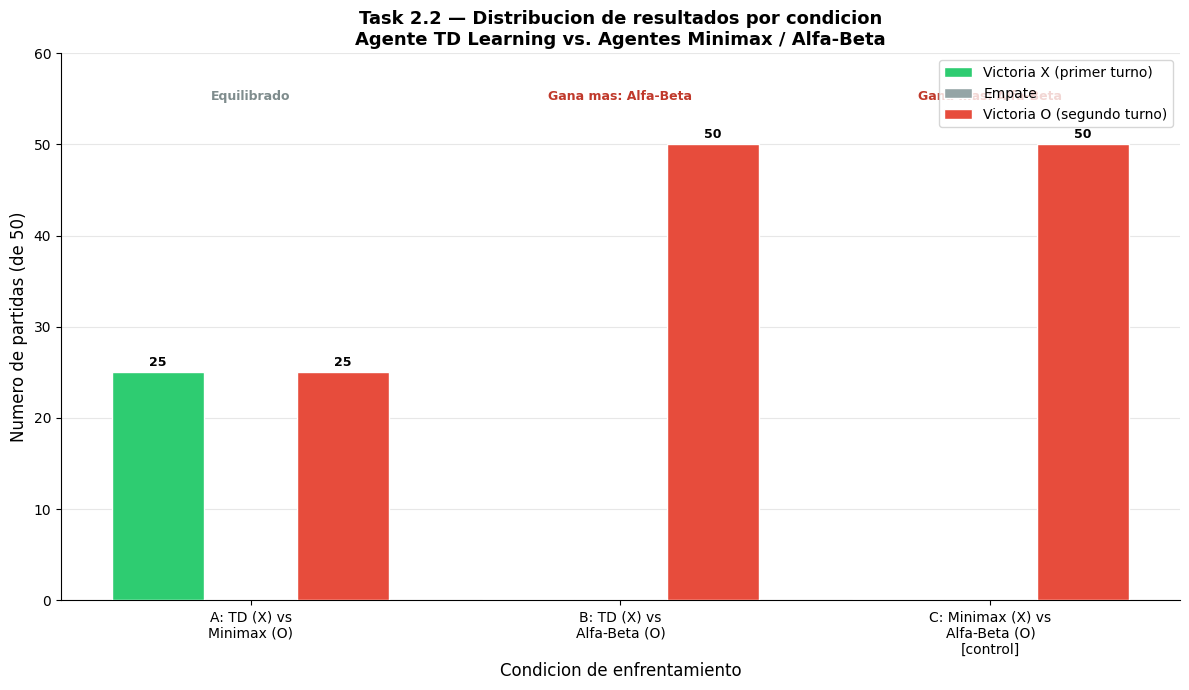

In [56]:
# Etiquetas de condicion con roles explícitos
conditions = [
    'A: TD (X) vs\nMinimax (O)',
    'B: TD (X) vs\nAlfa-Beta (O)',
    'C: Minimax (X) vs\nAlfa-Beta (O)\n[control]',
]

# Ganador de cada condicion desde la perspectiva de P1
# cond_X = (wins_p1, draws, wins_p2)
wins_p1 = [cond_A[0], cond_B[0], cond_C[0]]
draws   = [cond_A[1], cond_B[1], cond_C[1]]
wins_p2 = [cond_A[2], cond_B[2], cond_C[2]]

# Nombre del ganador por condicion (para anotacion)
winner_labels = [
    ('TD', 'Minimax'),
    ('TD', 'Alfa-Beta'),
    ('Minimax', 'Alfa-Beta'),
]

x     = np.arange(len(conditions))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width, wins_p1, width,
               label='Victoria X (primer turno)', color='#2ecc71', edgecolor='white', zorder=3)
bars2 = ax.bar(x,         draws,   width,
               label='Empate',                    color='#95a5a6', edgecolor='white', zorder=3)
bars3 = ax.bar(x + width, wins_p2, width,
               label='Victoria O (segundo turno)',color='#e74c3c', edgecolor='white', zorder=3)

# Valor numerico sobre cada barra
for bars in (bars1, bars2, bars3):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                    str(int(h)), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Anotacion del ganador neto por condicion
for i, (lp1, lp2) in enumerate(winner_labels):
    w1, d, w2 = wins_p1[i], draws[i], wins_p2[i]
    if w1 > w2:
        winner_txt, winner_col = f'Gana mas: {lp1}', '#27ae60'
    elif w2 > w1:
        winner_txt, winner_col = f'Gana mas: {lp2}', '#c0392b'
    else:
        winner_txt, winner_col = 'Equilibrado', '#7f8c8d'
    ax.text(x[i], N_GAMES + 4.5, winner_txt,
            ha='center', va='bottom', fontsize=9, color=winner_col, fontweight='bold')

ax.set_xlabel('Condicion de enfrentamiento', fontsize=12)
ax.set_ylabel(f'Numero de partidas (de {N_GAMES})', fontsize=12)
ax.set_title(
    'Task 2.2 — Distribucion de resultados por condicion\n'
    'Agente TD Learning vs. Agentes Minimax / Alfa-Beta',
    fontsize=13, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=10)
ax.set_ylim(0, N_GAMES + 10)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## Task 2.3 – Partidas representativas para el video

Se muestra **una partida completa por condicion** imprimiendo el tablero en cada turno. Estas son las partidas que se graban en el video.

In [57]:
def play_game_verbose(p1_fn, p2_fn, label=''):
    """
    Juega una partida completa imprimiendo el tablero en cada turno.
    Retorna el ganador ('X', 'O', o None para empate).
    """
    game = Connect4()
    current = PLAYER_1
    move_num = 0

    if label:
        print(f'\n{'='*45}')
        print(f'  {label}')
        print(f'{'='*45}')

    print('Tablero inicial:')
    game.print_board()

    while not game.is_terminal():
        move_num += 1
        col = p1_fn(game) if current == PLAYER_1 else p2_fn(game)
        if col is None:
            break
        game.make_move(col, current)
        player_label = 'X (Jugador 1)' if current == PLAYER_1 else 'O (Jugador 2)'
        print(f'  Turno {move_num}: {player_label} juega en columna {col + 1}')
        game.print_board()
        current = PLAYER_2 if current == PLAYER_1 else PLAYER_1

    w = game.winner()
    if w == PLAYER_1:
        print('Resultado: gana PLAYER_1 (X)')
    elif w == PLAYER_2:
        print('Resultado: gana PLAYER_2 (O)')
    else:
        print('Resultado: Empate')
    return w

In [58]:
# Condicion A: TD (X) vs Minimax (O)
play_game_verbose(td_fn_p1, mm_fn_p2, label='CONDICION A: Agente TD (X) vs Minimax puro d=4 (O)')

# Condicion B: TD (X) vs Alfa-Beta (O)
play_game_verbose(td_fn_p1, ab_fn_p2, label='CONDICION B: Agente TD (X) vs Alfa-Beta+Heuristica d=4 (O)')

# Condicion C: Minimax (X) vs Alfa-Beta (O)
play_game_verbose(mm_fn_p1, ab_fn_p2, label='CONDICION C (control): Minimax puro d=4 (X) vs Alfa-Beta d=4 (O)')


  CONDICION A: Agente TD (X) vs Minimax puro d=4 (O)
Tablero inicial:

*********************************
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
*********************************

  Turno 1: X (Jugador 1) juega en columna 4

*********************************
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   | X |   |   |   | *
*********************************

  Turno 2: O (Jugador 2) juega en columna 1

*********************************
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* |   |   |   |   |   |   |   | *
* | O |   |   | X |   |   |   | *
*********************************

  Turno 3: X (Jugad

'O'